# Lesson 22: KDD Cup 1999 network intrusion detection

This notebook uses the [KDD Cup 1999 network intrusion dataset](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html), a benchmark dataset built from simulated network traffic. Each row is one network connection described by 41 features: 38 numerical (e.g. duration, bytes transferred, number of failed login attempts) and 3 categorical (protocol type, network service, and connection flag). Connections are labeled either `normal` or as one of several attack types.

Although labels exist, we treat this as an **unsupervised** problem: all three main models (Isolation Forest, LOF, and Elliptic Envelope) are trained on features only with no access to labels. This mirrors the real-world scenario where labeled historical anomalies exist for evaluation but the model must generalize to new, unseen attacks without supervision.

**A note on label use:** labels appear in exactly three places in this notebook, each for a different reason:

1. **Row deduplication**: labels are temporarily added to ensure feature rows and their labels are removed together, then dropped immediately.

2. **Contamination estimate**: the true attack rate is used to calibrate all models' decision thresholds. This is threshold-setting, not model training; in a production setting you would use domain knowledge or historical incident rates instead.

3. **Evaluation**: labels are revealed at the end to measure how well each model found real attacks.

A formal train-test split is omitted because the models are fully unsupervised and learn no label-dependent parameters. The only label-informed decisions are in the feature selection and contamination estimation sections. In a real world application, this type of information would come from domain area knowledge and research on past attacks. So for the purpose of the demo, I'm calling it fair.

## 1. Notebook set up

### 1.1. Imports

In [1]:
'''KD Cup 99 unsupervised intrusion detection system design'''
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import fetch_kddcup99
from sklearn.decomposition import PCA#, TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.svm import OneClassSVM

### 1.2. Data loading

In [2]:
# Load the complete KDD Cup 1999 dataset from SKlearn
kdd = fetch_kddcup99(percent10=False, as_frame=True)
kdd_df = kdd.data # pylint: disable=no-member

print(f'Raw data is: {type(kdd)}')
print(f'Raw data contains: {", ".join(list(kdd.keys()))}\n')
print(f'DESCR:\n{kdd.DESCR}') # pylint: disable=no-member

kdd_df.head().T

Raw data is: <class 'sklearn.utils._bunch.Bunch'>
Raw data contains: data, target, frame, target_names, feature_names, DESCR

DESCR:
.. _kddcup99_dataset:

Kddcup 99 dataset
-----------------

The KDD Cup '99 dataset was created by processing the tcpdump portions
of the 1998 DARPA Intrusion Detection System (IDS) Evaluation dataset,
created by MIT Lincoln Lab [2]_. The artificial data (described on the `dataset's
homepage <https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html>`_) was
generated using a closed network and hand-injected attacks to produce a
large number of different types of attack with normal activity in the
background. As the initial goal was to produce a large training set for
supervised learning algorithms, there is a large proportion (80.1%) of
abnormal data which is unrealistic in real world, and inappropriate for
unsupervised anomaly detection which aims at detecting 'abnormal' data, i.e.:

* qualitatively different from normal data
* in large minority among the

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,b'tcp',b'tcp',b'tcp',b'tcp',b'tcp'
service,b'http',b'http',b'http',b'http',b'http'
flag,b'SF',b'SF',b'SF',b'SF',b'SF'
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


In [3]:
kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898431 entries, 0 to 4898430
Data columns (total 41 columns):
 #   Column                       Dtype 
---  ------                       ----- 
 0   duration                     object
 1   protocol_type                object
 2   service                      object
 3   flag                         object
 4   src_bytes                    object
 5   dst_bytes                    object
 6   land                         object
 7   wrong_fragment               object
 8   urgent                       object
 9   hot                          object
 10  num_failed_logins            object
 11  logged_in                    object
 12  num_compromised              object
 13  root_shell                   object
 14  su_attempted                 object
 15  num_root                     object
 16  num_file_creations           object
 17  num_shells                   object
 18  num_access_files             object
 19  num_outbound_cmds            obj

In [4]:
# Preserve labels for final evaluation
labels = kdd.target # pylint: disable=no-member
print(f'Labels contain: {", ".join(list(set(labels.astype(str))))}')

Labels contain: loadmodule., land., back., satan., perl., warezclient., guess_passwd., warezmaster., pod., buffer_overflow., ipsweep., rootkit., normal., imap., nmap., teardrop., multihop., smurf., spy., neptune., portsweep., ftp_write., phf.


## 2. Data cleaning

### 2.1. Labels

In [5]:
# Convert to string
labels = labels.astype(str)

### 2.2. Row deduplication

The original data contains a large number of duplicated rows - this can be trouble for things like isolation forest. The traffic pattern itself may be anomalous, but if it is repeated a large number of times those repeats make it appear to be normal traffic.

In [6]:
print(f'Duplicate rows: {kdd_df.duplicated().sum()}')

Duplicate rows: 3823457


De-duplicate the rows and add a feature indicating how many times each unique connection vector appeared in the original data.

In [7]:
# Temporarily add back the labels so row removal is consistent
kdd_df['labels'] = labels

# Remove duplicate rows and count occurrences
counts = kdd_df.groupby(kdd_df.columns.tolist(), as_index=False).size()
counts = counts.rename(columns={'size': 'occurrences'})
kdd_df = kdd_df.drop_duplicates().merge(counts, on=kdd_df.columns.to_list(), how='left')

# Update and then remove the labels
labels = kdd_df['labels']
kdd_df.drop('labels', axis=1, inplace=True)

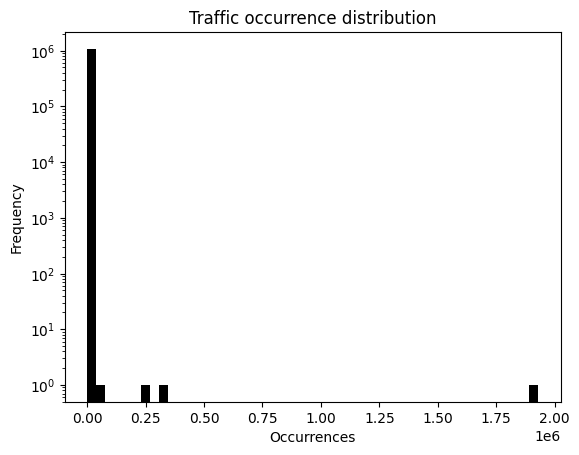

In [8]:
plt.title('Traffic occurrence distribution')
plt.hist(kdd_df['occurrences'], bins=50, color='black')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

### 2.3. Feature definitions

In [9]:
# Define string, int and float features
string_features = [
    'protocol_type', 'service', 'flag'
]

int_features = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'dst_host_count',
    'dst_host_srv_count',
    'occurrences',
]

float_features = [
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]


In [10]:
# Clean binary encoded features
kdd_df[string_features] = kdd_df[string_features].astype('string')

# Set feature data types
kdd_df[string_features] = kdd_df[string_features].astype('category')
kdd_df[int_features] = kdd_df[int_features].astype('int')
kdd_df[float_features] = kdd_df[float_features].astype('float')

kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   duration                     1074992 non-null  int64   
 1   protocol_type                1074992 non-null  category
 2   service                      1074992 non-null  category
 3   flag                         1074992 non-null  category
 4   src_bytes                    1074992 non-null  int64   
 5   dst_bytes                    1074992 non-null  int64   
 6   land                         1074992 non-null  int64   
 7   wrong_fragment               1074992 non-null  int64   
 8   urgent                       1074992 non-null  int64   
 9   hot                          1074992 non-null  int64   
 10  num_failed_logins            1074992 non-null  int64   
 11  logged_in                    1074992 non-null  int64   
 12  num_compromised              1074992 no

In [11]:
kdd_df.head().T

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,tcp,tcp,tcp,tcp,tcp
service,http,http,http,http,http
flag,SF,SF,SF,SF,SF
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


## 3. EDA & pre-processing

### 3.1. String (categorical) features

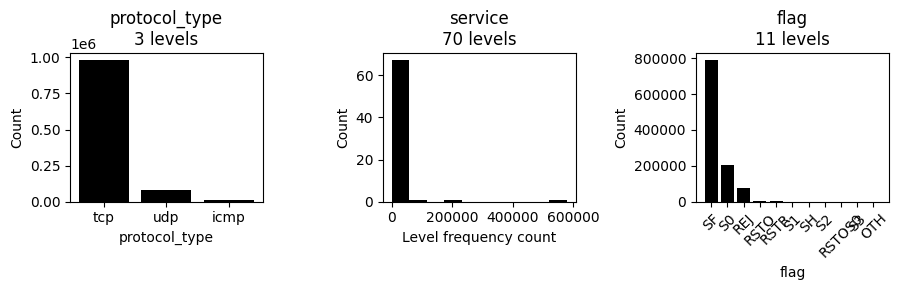

In [12]:
fig, axes = plt.subplots(
    math.ceil(len(string_features) / 3),
    3,
    figsize=(9, math.ceil(len(string_features) / 3) * 3)
)

axes = axes.flatten()

for i, feature in enumerate(string_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} levels')

    if len(counts) > 20:
        axes[i].hist(counts.values, bins=10, color='black')
        axes[i].set_xlabel('Level frequency count')
        axes[i].set_ylabel('Count')

    else:
        axes[i].bar(counts.index.astype(str), counts.values, color='black')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

        if len(counts) > 10:
            axes[i].tick_params(axis='x', rotation=45)

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

Thinking we should use try one-hot here - we are going to end up with > 80 features, but we can just SVD or PCA them later if needed. This approach preserves the information content better than hashing and does not impose arbitrary order like ordinal encoding.

In [13]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(kdd_df[string_features])

encoded_feature_names = encoder.get_feature_names_out()

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoded_feature_names
)

kdd_df = pd.concat([kdd_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
kdd_df.drop(string_features, axis=1, inplace=True)
kdd_df[encoded_feature_names] = kdd_df[encoded_feature_names].astype('int')

### 3.2. Integer (count) features

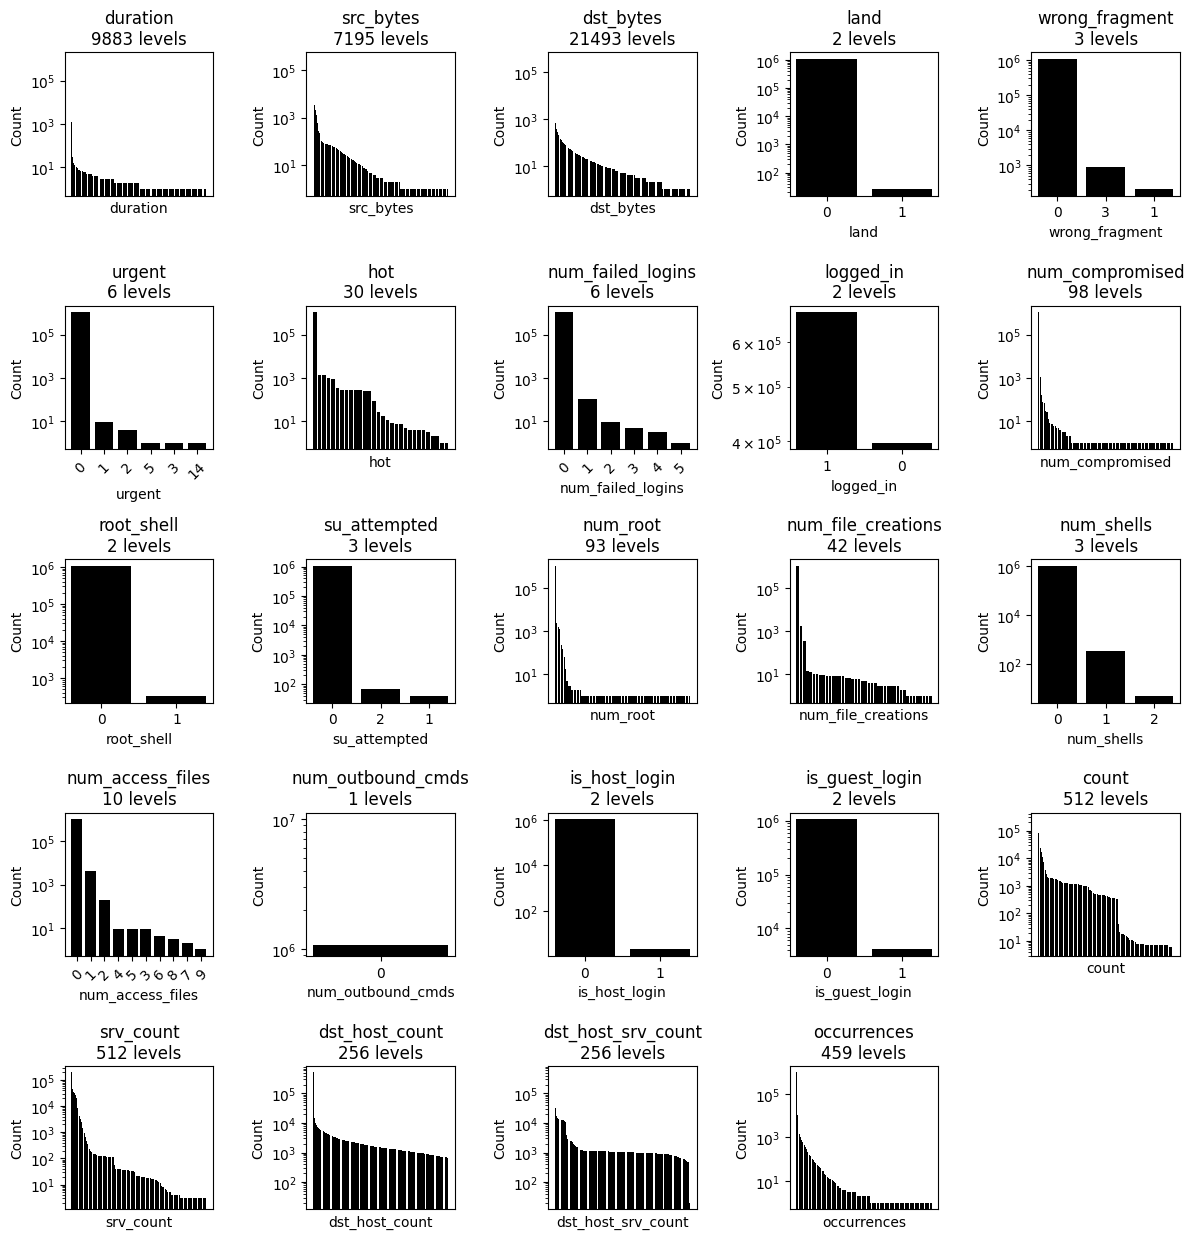

In [14]:
fig, axes = plt.subplots(
    math.ceil(len(int_features) / 5),
    5,
    figsize=(12, math.ceil(len(int_features) / 5) * 2.5)
)

axes = axes.flatten()

for i, feature in enumerate(int_features):

    counts = kdd_df[feature].value_counts()
    axes[i].set_title(f'{feature}\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

OK - a few things jump out right away:

1. The integer features are a mix of high and low cardinality. Some are binary, while at the other extreme, some have thousands of levels.
2. Most low cardinality features are dominated by one category (see `land` or `wrong_fragment` and note log scale y-axis), while high cardinality features often have many levels that show up only a few times, and some that show up many times (see `num_root` or `num_compromised` and again note log y-axis).
3. `num_outbound_cmds` is constant and can be dropped.

Let's break the integer features into finer categories so we can handle the cases differently.

1. **Binary** (ex: `land`, `logged_in`): leave as 0/1 encoding and cast to bool.
2. **Low cardinality count** (ex: `num_failed_logins`): leave as ordinal encoding.
3. **Skewed high cardinality count** (ex: `src_bytes`): frequency encode.

In [15]:
# Drop constant feature
kdd_df.drop('num_outbound_cmds', axis=1, inplace=True)
int_features.remove('num_outbound_cmds')

In [16]:
# New feature subset definitions for integer features
binary_features = []
low_cardinality = []
high_cardinality = []

for feature in int_features:
    if kdd_df[feature].nunique() == 2:
        binary_features.append(feature)

    elif kdd_df[feature].nunique() < 50:
        low_cardinality.append(feature)

    elif kdd_df[feature].nunique() >= 50:
        high_cardinality.append(feature)

    else:
        print(f"Don't know what to do with {feature}")

print(f'Binary features: {", ".join(binary_features)}\n')
print(f'Low cardinality features: {", ".join(low_cardinality)}\n')
print(f'High cardinality features: {", ".join(high_cardinality)}\n')
print(f'Total integer features: {len(binary_features + low_cardinality + high_cardinality)}')

Binary features: land, logged_in, root_shell, is_host_login, is_guest_login

Low cardinality features: wrong_fragment, urgent, hot, num_failed_logins, su_attempted, num_file_creations, num_shells, num_access_files

High cardinality features: duration, src_bytes, dst_bytes, num_compromised, num_root, count, srv_count, dst_host_count, dst_host_srv_count, occurrences

Total integer features: 23


In [17]:
# Set type for binary features
kdd_df[binary_features] = kdd_df[binary_features].astype('bool')

# Set type for low cardinality features
kdd_df[low_cardinality] = kdd_df[low_cardinality].astype('int')

Now let's take a look at the high cardinality features:

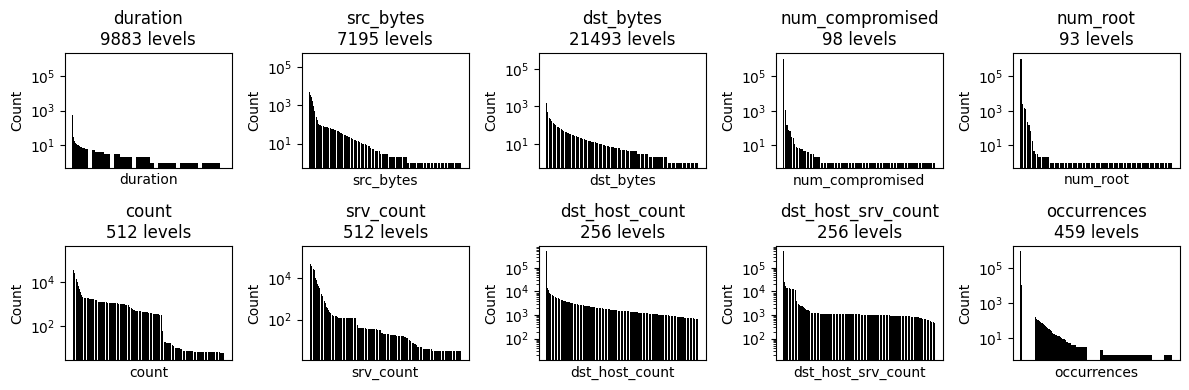

In [18]:
fig, axes = plt.subplots(
    math.ceil(len(high_cardinality) / 5),
    5,
    figsize=(12, math.ceil(len(high_cardinality) / 5) * 2)
)

axes = axes.flatten()

for i, feature in enumerate(high_cardinality):

    counts = kdd_df[feature].value_counts()
    axes[i].set_title(f'{feature}\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

Last transformation - frequency encode the high cardinality integer features.

In [19]:
freq_features = {}

for feature in high_cardinality:
    freq_map = kdd_df[feature].value_counts()
    freq_features[f'{feature}_freq'] = kdd_df[feature].map(freq_map)

# Concat once to avoid per-column fragmentation warnings
kdd_df = pd.concat([kdd_df, pd.DataFrame(freq_features)], axis=1)

In [20]:
kdd_df[[f'{feature}_freq' for feature in high_cardinality]].info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 10 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   duration_freq            1074992 non-null  int64
 1   src_bytes_freq           1074992 non-null  int64
 2   dst_bytes_freq           1074992 non-null  int64
 3   num_compromised_freq     1074992 non-null  int64
 4   num_root_freq            1074992 non-null  int64
 5   count_freq               1074992 non-null  int64
 6   srv_count_freq           1074992 non-null  int64
 7   dst_host_count_freq      1074992 non-null  int64
 8   dst_host_srv_count_freq  1074992 non-null  int64
 9   occurrences_freq         1074992 non-null  int64
dtypes: int64(10)
memory usage: 82.0 MB


In [21]:
# kdd_df.head().T

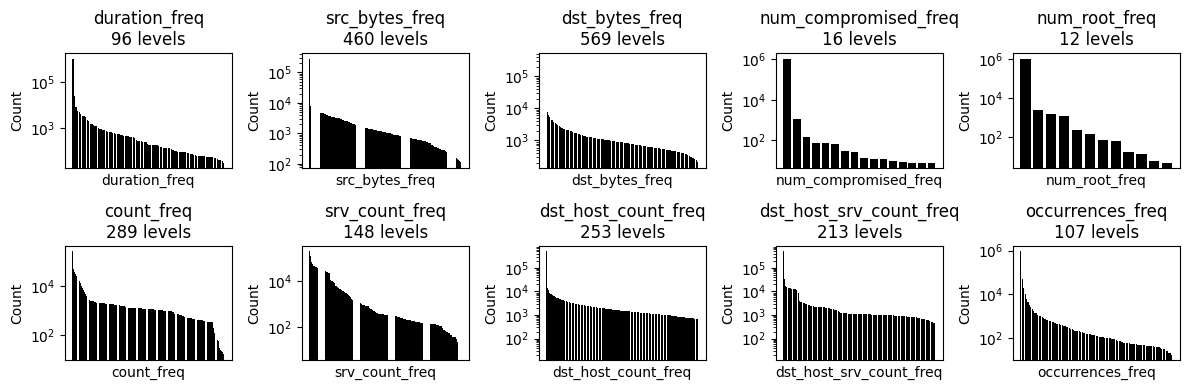

In [22]:
fig, axes = plt.subplots(
    math.ceil(len(high_cardinality) / 5),
    5,
    figsize=(12, math.ceil(len(high_cardinality) / 5) * 2)
)

axes = axes.flatten()

for i, feature in enumerate(high_cardinality):

    counts = kdd_df[f'{feature}_freq'].value_counts()
    axes[i].set_title(f'{feature}_freq\n{len(counts)} levels')
    axes[i].bar(counts.index.astype(str), counts.values, color='black')
    axes[i].set_xlabel(f'{feature}_freq')
    axes[i].set_ylabel('Count')

    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)

    # Turn off x-ticks for features with too many levels to avoid clutter
    if len(counts) > 10:
        axes[i].set_xticks([])

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

**Note**: we will standard scale everything together once at the end of the feature engineering before training models.

### 3.3. Float (continuous) features

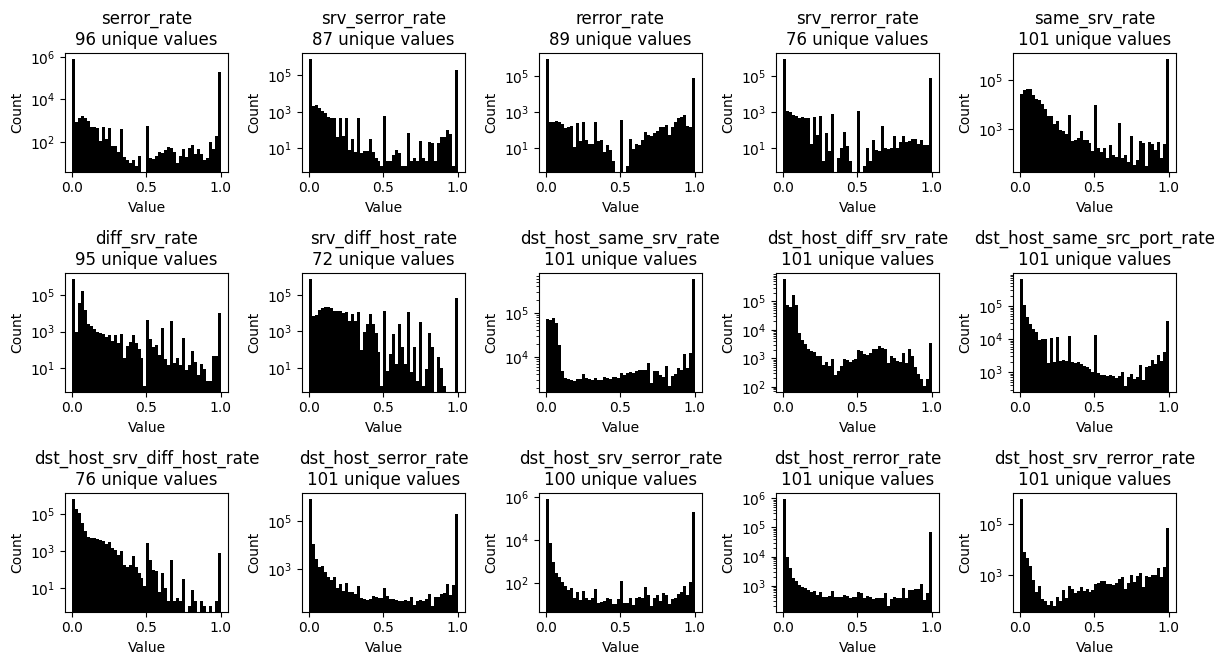

In [23]:
n_cols = 5

fig, axes = plt.subplots(
    math.ceil(len(float_features) / n_cols),
    n_cols,
    figsize=(12, math.ceil(len(float_features) / n_cols) * 2.25)
)

axes = axes.flatten()

for i, feature in enumerate(float_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} unique values')
    axes[i].hist(kdd_df[feature], bins=50, color='black')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()
plt.show()

Some of these have considerably lower cardinality than our integer/'categorical' features. But, the values are a little more more spread over the ranges. Let's keep things simple and just power transform.

In [24]:
# Power transform the continuous features
transformer = PowerTransformer(method='yeo-johnson', standardize=True)
kdd_df[float_features] = transformer.fit_transform(kdd_df[float_features])

## 4. Feature selection and engineering

Feature selection identifies which features contain the most discriminative signal, reduces uninformative noise, and decorrelates the input via PCA. All three anomaly detectors are fitted on the same 9-component PCA representation.

### 4.1. Scaling and contamination estimate

Two preparatory steps before fitting any models:

- **Contamination estimate**: compute the true attack rate from the deduplicated labels to calibrate both models' decision thresholds.

- **StandardScaler**: required for meaningful SVD or PCA decomposition and for the distance metrics used in unsupervised anomaly detection models.

In [25]:
# Label use #2: contamination calibrates the decision threshold, not the model itself
attack_count = (labels != 'normal.').sum()
total_count = len(labels)
contamination = attack_count / total_count

print(f'Total unique connection patterns: {total_count:,}')
print(f'Attack patterns:  {attack_count:,} ({contamination:.1%})')
print(f'Normal patterns:  {total_count - attack_count:,} ({1 - contamination:.1%})')

# Label use #3: binary labels stored for evaluation at the end, not used in training
encoded_labels = np.array([0 if label == 'normal.' else 1 for label in labels])

scaler = StandardScaler()
scaled_kdd_df = pd.DataFrame(scaler.fit_transform(kdd_df), columns=kdd_df.columns)

Total unique connection patterns: 1,074,992
Attack patterns:  262,178 (24.4%)
Normal patterns:  812,814 (75.6%)


### 4.2. Feature-label association



Although labels are not used in model training, we can analyze which features best discriminate normal from attack traffic using the **standardized mean difference** (Cohen's d): the gap between group means in units of pooled standard deviation. This is an effect size, not a hypothesis test; no p-values, no multiple-testing correction needed.

In [26]:
feature_stats = []

for col in scaled_kdd_df.columns:

    normal_vals = scaled_kdd_df.loc[encoded_labels == 0, col]
    attack_vals = scaled_kdd_df.loc[encoded_labels == 1, col]

    pooled_std = np.sqrt((normal_vals.var() + attack_vals.var()) / 2)
    effect_size = abs(attack_vals.mean() - normal_vals.mean()) / (pooled_std + 1e-10)

    feature_stats.append({
        'feature': col,
        'effect_size': round(effect_size, 4),
        'mean_normal': round(normal_vals.mean(), 4),
        'mean_attack': round(attack_vals.mean(), 4),
    })

feature_stats_df = pd.DataFrame(feature_stats).sort_values(
    'effect_size',
    ascending=False
).reset_index(drop=True)

feature_stats_df.head(20)

,feature,effect_size,mean_normal,mean_attack
0,same_srv_rate,4.9819,0.5277,-1.6359
1,flag_SF,4.2695,0.4986,-1.5458
2,src_bytes_freq,4.1823,-0.4978,1.5433
3,diff_srv_rate,4.1722,-0.5028,1.5586
4,dst_bytes_freq,3.7859,-0.4562,1.4144
5,dst_host_same_srv_rate,3.1205,0.4338,-1.3450
6,dst_host_srv_count,3.0810,0.4228,-1.3108
7,logged_in,3.0250,0.4159,-1.2893
8,dst_host_serror_rate,2.6441,-0.4810,1.4913
9,serror_rate,2.6357,-0.4807,1.4904


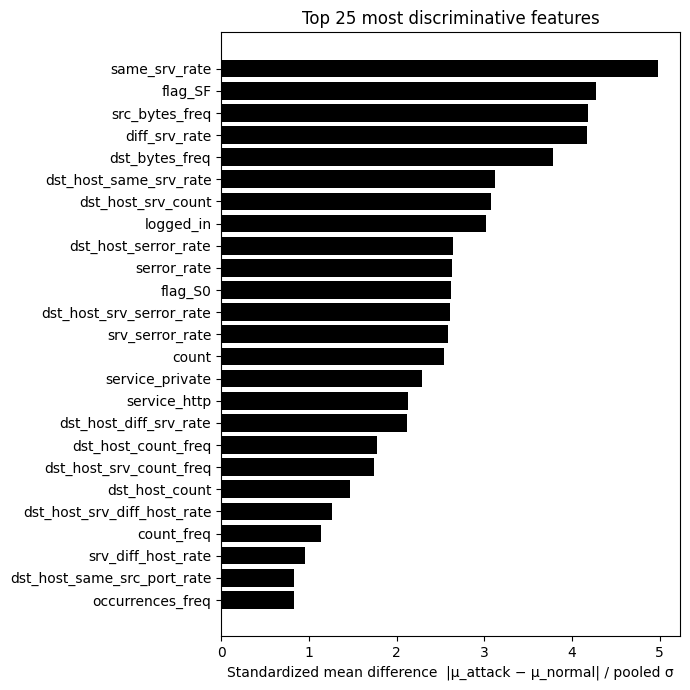

In [27]:
top_n = 25
top_features = feature_stats_df.head(top_n)

fig, ax = plt.subplots(figsize=(7, 7))

ax.barh(top_features['feature'].iloc[::-1], top_features['effect_size'].iloc[::-1], color='black')
ax.set_xlabel('Standardized mean difference  |μ_attack − μ_normal| / pooled σ')
ax.set_title(f'Top {top_n} most discriminative features')

plt.tight_layout()
plt.show()

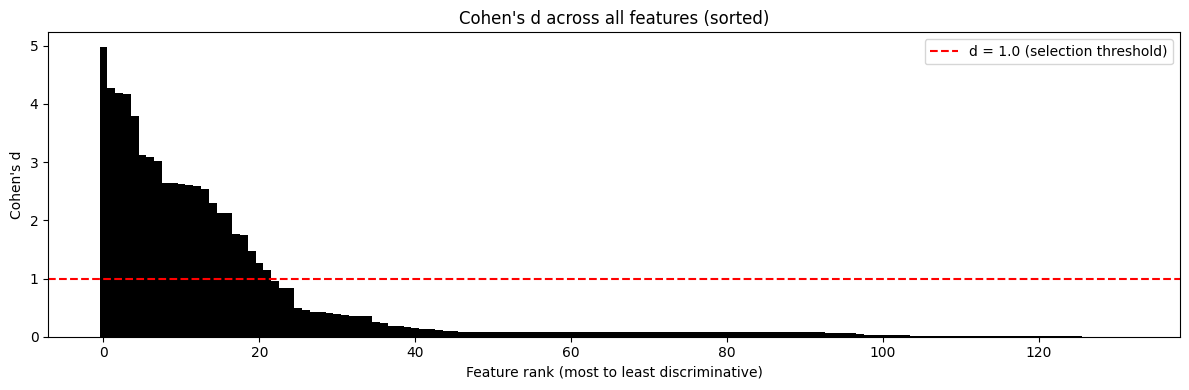

In [28]:
# Sorted bar chart of all Cohen's d values to see the full spread and choose a threshold
threshold = 1.0

fig, ax = plt.subplots(figsize=(12, 4))

sorted_d = feature_stats_df['effect_size'].sort_values(ascending=False).reset_index(drop=True)

ax.bar(range(len(sorted_d)), sorted_d, color='black', width=1.0)
ax.axhline(threshold, color='red', linestyle='--', label=f'd = {threshold} (selection threshold)')
ax.set_xlabel('Feature rank (most to least discriminative)')
ax.set_ylabel("Cohen's d")
ax.set_title("Cohen's d across all features (sorted)")
ax.legend()

plt.tight_layout()
plt.show()

Next, select features with a threshold of 1 (i.e. Cohen's d > 1) meaning the attack and normal groups differ by at least one pooled standard deviation. Then deduplicate again based on the reduced feature set.

In [29]:
# Keep features where the two groups are at least one pooled-std apart
selected_features = feature_stats_df.loc[feature_stats_df['effect_size'] >= threshold, 'feature'].tolist()
X_selected = scaled_kdd_df[selected_features]

# Deduplicate rows to avoid biasing the model with repeated patterns
duplicate_rows = X_selected.duplicated(keep='first')
X_selected = X_selected.loc[~duplicate_rows].reset_index(drop=True)
encoded_labels = encoded_labels[~duplicate_rows.to_numpy()]

# Recalculate contamination after deduplication
attack_count = encoded_labels.sum()
total_count = len(encoded_labels)
contamination = attack_count / total_count

print(f'Selected {len(selected_features)} of {scaled_kdd_df.shape[1]} features (d >= {threshold})')
print(f'Duplicate selected feature rows removed: {duplicate_rows.sum():,}')
print(f'Model rows after deduplication: {total_count:,}')
print(f'Attack patterns after deduplication: {attack_count:,} ({contamination:.1%})')

Selected 22 of 132 features (d >= 1.0)
Duplicate selected feature rows removed: 120,816
Model rows after deduplication: 954,176
Attack patterns after deduplication: 215,612 (22.6%)


### 4.3. PCA pre-processing

The density analysis in section 8 shows that attack traffic clusters away from normal traffic along the first principal component. Working in PCA space rather than the raw feature space has two advantages:

- **Decorrelated dimensions**: each component is orthogonal, so axis-aligned splits in Isolation Forest are not wasted navigating correlated features.
- **Compact normal region**: normal traffic forms a tight Gaussian ellipse in PCA space: exactly the shape Elliptic Envelope exploits to define the inlier boundary.

Nine components capture 95% of the variance in the selected feature set.

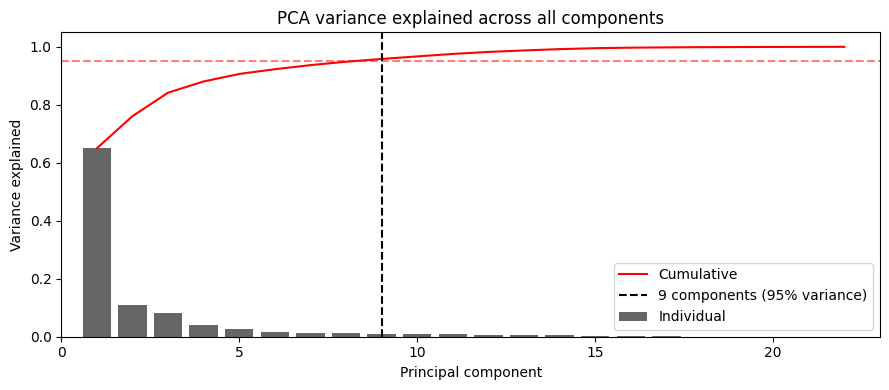

Components for 95% variance: 9 (from 22 selected features)
Variance captured: 95.8%


In [30]:
pca_full = PCA(random_state=315).fit(X_selected)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumvar >= 0.95)) + 1

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    range(1, len(cumvar) + 1),
    pca_full.explained_variance_ratio_,
    color='black', alpha=0.6, label='Individual'
)

ax.plot(range(1, len(cumvar) + 1), cumvar, color='red', label='Cumulative')
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5)

ax.axvline(
    n_components,
    color='black',
    linestyle='--',
    label=f'{n_components} components (95% variance)'
)

ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained')
ax.set_title('PCA variance explained across all components')
ax.set_xlim(0, len(cumvar) + 1)
ax.legend()

plt.tight_layout()
plt.show()

pca_prep = PCA(n_components=n_components, random_state=315)
X_pca = pca_prep.fit_transform(X_selected)

print(f'Components for 95% variance: {n_components} (from {X_selected.shape[1]} selected features)')
print(f'Variance captured: {pca_prep.explained_variance_ratio_.sum():.1%}')

## 5. Isolation forest

Fit on the 9-component PCA representation. `score_samples()` returns the raw anomaly score before thresholding; lower is more anomalous.

Isolation Forest: 215612 anomalies detected (22.6%)


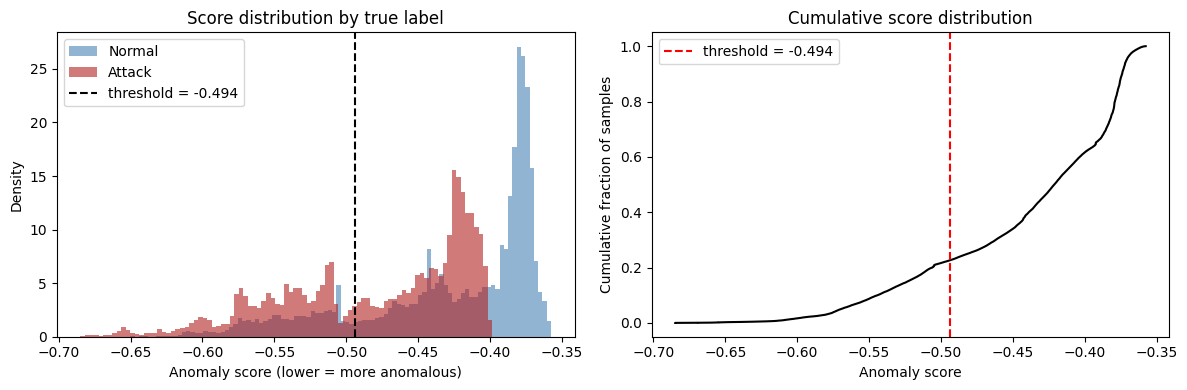

In [31]:
iso_forest = IsolationForest(contamination=contamination, random_state=315)
iso_forest_labels = iso_forest.fit_predict(X_pca)

n_outliers = (iso_forest_labels == -1).sum()

print(
    f'Isolation Forest: {n_outliers} anomalies detected ' +
    f'({n_outliers / len(iso_forest_labels):.1%})'
)

scores = iso_forest.score_samples(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, name, color in [(0, 'Normal', 'steelblue'), (1, 'Attack', 'firebrick')]:
    axes[0].hist(
        scores[encoded_labels == val],
        bins=100, alpha=0.6, color=color, label=name, density=True
    )

axes[0].axvline(
    iso_forest.offset_,
    color='black',
    linestyle='--',
    label=f'threshold = {iso_forest.offset_:.3f}'
)

axes[0].set_title('Score distribution by true label')
axes[0].set_xlabel('Anomaly score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_scores = np.sort(scores)

axes[1].plot(sorted_scores, np.linspace(0, 1, len(sorted_scores)), color='black')

axes[1].axvline(
    iso_forest.offset_,
    color='red',
    linestyle='--',
    label=f'threshold = {iso_forest.offset_:.3f}'
)

axes[1].set_title('Cumulative score distribution')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Cumulative fraction of samples')
axes[1].legend()

plt.tight_layout()
plt.show()

OK - I see signal: that big blue peak above the range of the attack distribution represents normal traffic that is being correctly identified as 'less anomalous' than any of the attack traffic. But, there is still a huge overlap between attack and normal traffic (see all of the blue under the red distribution). Also, at the current threshold, we are going to have a lot of false negatives!

## 6. Local Outlier Factor

LOF detects anomalies by comparing each point's local density to the density of its neighbors. Unlike Isolation Forest, which relies on globally isolating points, LOF can flag anomalies that only stand out relative to their local neighborhood. Fitted on the same PCA features for a fair comparison with the other models.

In [32]:
lof = LocalOutlierFactor(contamination=contamination, n_neighbors=20)
lof_labels = lof.fit_predict(X_pca)
lof_scores = lof.negative_outlier_factor_

n_outliers_lof = (lof_labels == -1).sum()
print(f'LOF: {n_outliers_lof} anomalies detected ({n_outliers_lof / len(lof_labels):.1%})')

LOF: 215612 anomalies detected (22.6%)


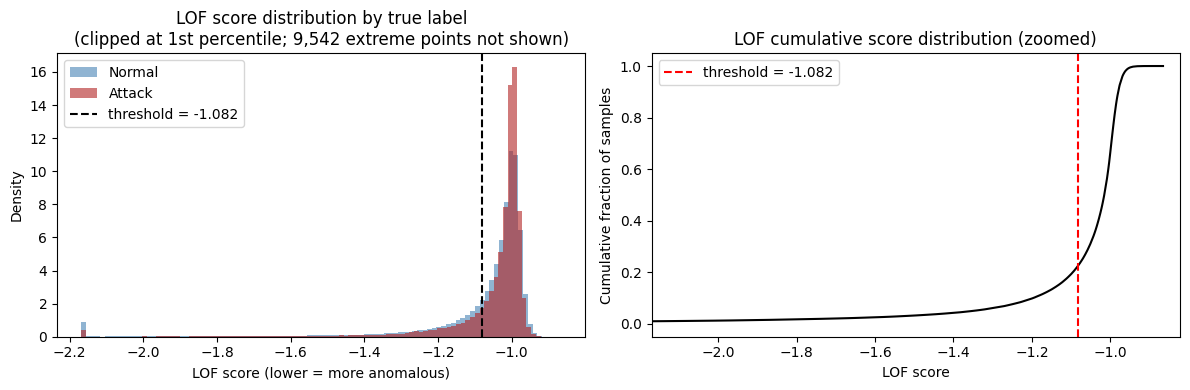

In [33]:
# Clip display range to the 1st percentile so extreme outliers don't compress the bulk.
clip_min = np.percentile(lof_scores, 1)
clip_max = lof_scores.max()
n_extreme = (lof_scores < clip_min).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, name, color in [(0, 'Normal', 'steelblue'), (1, 'Attack', 'firebrick')]:
    axes[0].hist(
        np.clip(lof_scores[encoded_labels == val], clip_min, 0),
        bins=100,
        alpha=0.6,
        color=color,
        label=name,
        density=True
    )

axes[0].axvline(
    lof.offset_,
    color='black',
    linestyle='--',
    label=f'threshold = {lof.offset_:.3f}'
)

axes[0].set_title(
    'LOF score distribution by true label\n' +
    f'(clipped at 1st percentile; {n_extreme:,} extreme points not shown)'
)

axes[0].set_xlabel('LOF score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_lof_scores = np.sort(lof_scores)

axes[1].plot(sorted_lof_scores, np.linspace(0, 1, len(sorted_lof_scores)), color='black')
axes[1].axvline(lof.offset_, color='red', linestyle='--', label=f'threshold = {lof.offset_:.3f}')
axes[1].set_xlim(clip_min, clip_max * 0.95)
axes[1].set_title('LOF cumulative score distribution (zoomed)')
axes[1].set_xlabel('LOF score')
axes[1].set_ylabel('Cumulative fraction of samples')
axes[1].legend()

plt.tight_layout()
plt.show()

Worse result that the isolation forest - almost no discriminative power here. Attack and normal distributions are almost identical. The LOF model is not able to separate the two groups hardly at at all.

## 7. Elliptic Envelope

Elliptic Envelope fits a robust multivariate Gaussian to the training data using the minimum covariance determinant (MCD) estimator, then flags points whose shifted Mahalanobis distance falls below the decision boundary as anomalies. It is the natural choice when normal traffic forms a compact, approximately elliptical cloud, which the PCA density maps confirm is the case here.

`decision_function()` returns the shifted Mahalanobis distance: positive values indicate inliers, negative values indicate outliers.

Elliptic Envelope: 215612 anomalies detected (22.6%)


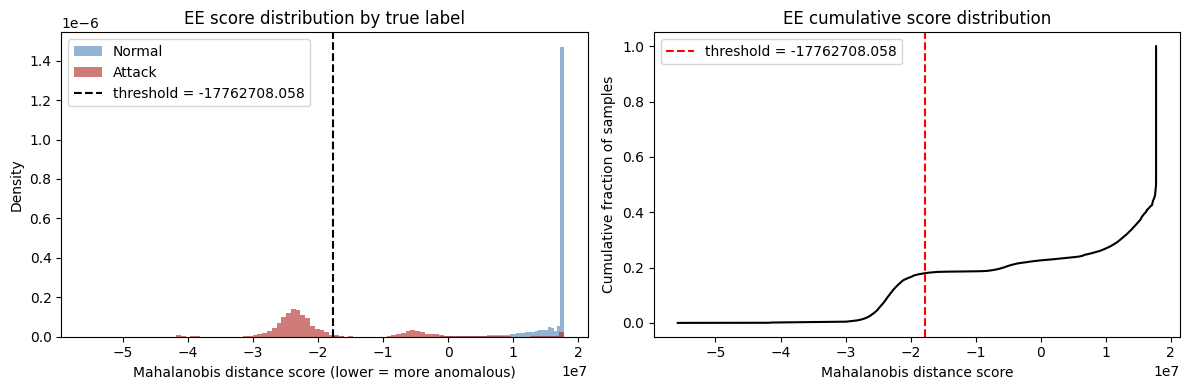

In [34]:
ee = EllipticEnvelope(contamination=contamination, random_state=315)
ee_labels = ee.fit_predict(X_pca)
ee_scores = ee.decision_function(X_pca)

n_outliers_ee = (ee_labels == -1).sum()

print(
    f'Elliptic Envelope: {n_outliers_ee} anomalies ' +
    f'detected ({n_outliers_ee / len(ee_labels):.1%})'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, name, color in [(0, 'Normal', 'steelblue'), (1, 'Attack', 'firebrick')]:
    axes[0].hist(
        ee_scores[encoded_labels == val],
        bins=100, alpha=0.6, color=color, label=name, density=True
    )

axes[0].axvline(
    ee.offset_,
    color='black',
    linestyle='--',
    label=f'threshold = {ee.offset_:.3f}'
)

axes[0].set_title('EE score distribution by true label')
axes[0].set_xlabel('Mahalanobis distance score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_ee = np.sort(ee_scores)

axes[1].plot(sorted_ee, np.linspace(0, 1, len(sorted_ee)), color='black')

axes[1].axvline(
    ee.offset_,
    color='red',
    linestyle='--',
    label=f'threshold = {ee.offset_:.3f}'
)

axes[1].set_title('EE cumulative score distribution')
axes[1].set_xlabel('Mahalanobis distance score')
axes[1].set_ylabel('Cumulative fraction of samples')
axes[1].legend()

plt.tight_layout()
plt.show()

This one looks the best so far. Most of the normal traffic is stacked up at the high end of the distribution, while the attack appear in two peaks at lower scores. The looks too low, but at least we are able to resolve the two traffic distributions.

## 8. Evaluation

Labels are revealed here for the first time to measure how well each model found real attacks. All three models were trained on features only; contamination was used only to calibrate the decision threshold, not to supervise the learning.

### 8.1. Scatter plots

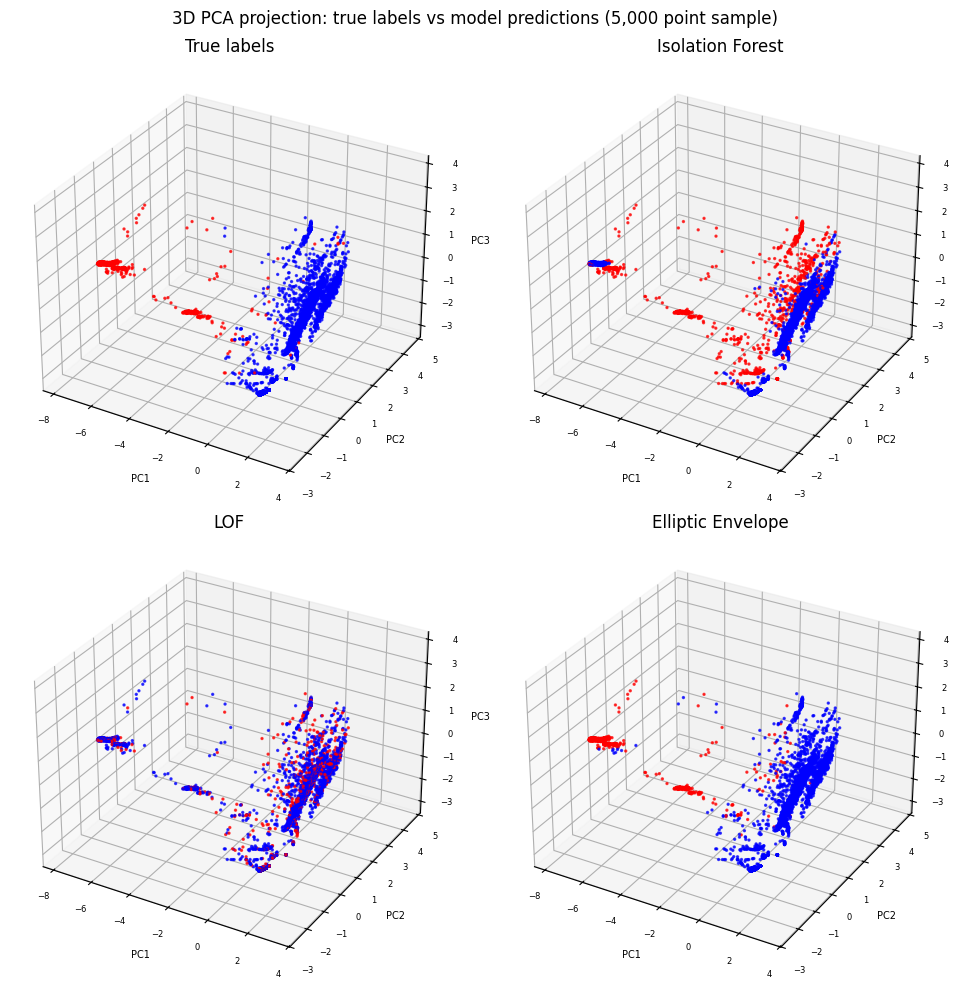

In [35]:
def to_binary(raw_labels):
    '''Helper function to binarize labels for plotting.
    Converts -1 to 1 (anomaly) and 1 to 0 (normal).'''

    return (np.array(raw_labels) == -1).astype(int)

# Sample to avoid overplotting; use first 3 PCA components for the 3D projection.
sample_n = 5000
rng_eval = np.random.default_rng(315)
sample_idx = rng_eval.choice(len(X_pca), size=sample_n, replace=False)
X_3d = X_pca[sample_idx, :3]

fig = plt.figure(figsize=(10, 10))
fig.suptitle(f'3D PCA projection: true labels vs model predictions ({sample_n:,} point sample)')

for i, (title, pred_all) in enumerate(zip(
    ['True labels', 'Isolation Forest', 'LOF', 'Elliptic Envelope'],
    [encoded_labels, to_binary(iso_forest_labels), to_binary(lof_labels), to_binary(ee_labels)],
)):

    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    pred_sample = pred_all[sample_idx]

    ax.scatter(
        X_3d[:, 0],
        X_3d[:, 1],
        X_3d[:, 2],
        c=pred_sample,
        cmap='bwr',
        s=2,
        alpha=0.7
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('PC1', fontsize=7)
    ax.set_ylabel('PC2', fontsize=7)
    ax.set_zlabel('PC3', fontsize=7)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

### 8.2. Precision-recall curves

The area under the precision-recall curve (AP) measures discrimination ability across all possible thresholds, independent of any contamination setting. AP = 1.0 is perfect; AP equal to the attack rate (0.226) is no better than random.

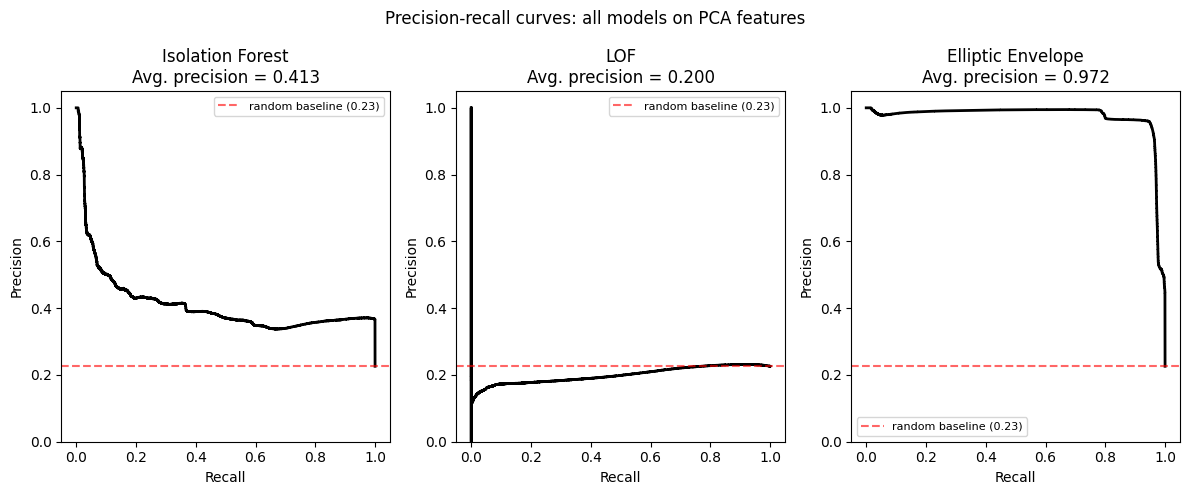

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Precision-recall curves: all models on PCA features')

for ax, (name, raw_scores) in zip(axes, [
    ('Isolation Forest',  iso_forest.score_samples(X_pca)),
    ('LOF',               lof_scores),
    ('Elliptic Envelope', ee_scores),
]):

    # Negate: sklearn PR curve expects higher score = more likely positive (attack).
    prec_vals, rec_vals, _ = precision_recall_curve(encoded_labels, -raw_scores)
    ap = average_precision_score(encoded_labels, -raw_scores)

    ax.plot(rec_vals, prec_vals, color='black', linewidth=2)

    ax.axhline(
        contamination,
        color='red',
        linestyle='--',
        alpha=0.6,
        label=f'random baseline ({contamination:.2f})'
    )

    ax.set_title(f'{name}\nAvg. precision = {ap:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Threshold tuning

All three models were fitted at the true contamination rate (0.226). The threshold scan below sweeps contamination values to reveal each model's precision/recall trade-off and identify optimal operating points.

- **Lower contamination** → fewer flags → higher precision (fewer false alarms), lower recall.
- **Higher contamination** → more flags → higher recall, lower precision.

The score arrays for sweeping:
- **Isolation Forest**: `score_samples(X_pca)`: lower is more anomalous.
- **LOF**: `negative_outlier_factor_`: lower is more anomalous.
- **Elliptic Envelope**: `decision_function(X_pca)`: lower is more anomalous.

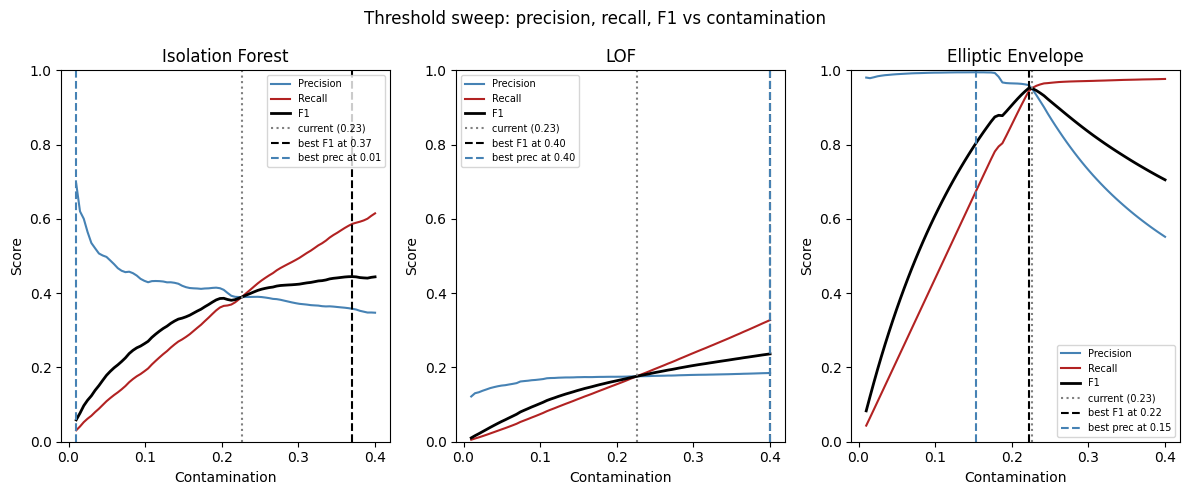

Optimal thresholds:

  Isolation Forest
    Best F1:        cont=0.370  P=0.358  R=0.587  F1=0.445
    Best precision: cont=0.010  P=0.695  R=0.031  F1=0.059

  LOF
    Best F1:        cont=0.400  P=0.185  R=0.328  F1=0.236
    Best precision: cont=0.400  P=0.185  R=0.328  F1=0.236

  Elliptic Envelope
    Best F1:        cont=0.222  P=0.960  R=0.944  F1=0.952
    Best precision: cont=0.153  P=0.995  R=0.674  F1=0.804


In [37]:
contamination_values = np.linspace(0.01, 0.40, 80)

sweep_results = {
    'Isolation Forest':  (iso_forest.score_samples(X_pca), []),
    'LOF':               (lof_scores,                      []),
    'Elliptic Envelope': (ee_scores,                       []),
}

for cont in contamination_values:
    for name, (raw_scores, store) in sweep_results.items():

        thresh = np.percentile(raw_scores, cont * 100)
        preds = (raw_scores < thresh).astype(int)

        store.append({
            'contamination': cont,
            'precision': precision_score(encoded_labels, preds, zero_division=0),
            'recall':    recall_score(encoded_labels, preds, zero_division=0),
            'f1':        f1_score(encoded_labels, preds, zero_division=0),
        })

sweep_dfs = {name: pd.DataFrame(store) for name, (_, store) in sweep_results.items()}

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Threshold sweep: precision, recall, F1 vs contamination')

for ax, (name, df) in zip(axes, sweep_dfs.items()):

    f1_best_cont   = df.loc[df['f1'].idxmax(),        'contamination']
    prec_best_cont = df.loc[df['precision'].idxmax(), 'contamination']

    ax.plot(df['contamination'], df['precision'], label='Precision', color='steelblue')
    ax.plot(df['contamination'], df['recall'],    label='Recall',    color='firebrick')
    ax.plot(df['contamination'], df['f1'],        label='F1',        color='black', linewidth=2)

    ax.axvline(
        contamination,
        color='grey',
        linestyle=':', 
        label=f'current ({contamination:.2f})'
    )

    ax.axvline(
        f1_best_cont,
        color='black',
        linestyle='--',
        label=f'best F1 at {f1_best_cont:.2f}'
    )

    ax.axvline(
        prec_best_cont,
        color='steelblue',
        linestyle='--',
        label=f'best prec at {prec_best_cont:.2f}'
    )

    ax.set_title(name)
    ax.set_xlabel('Contamination')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print('Optimal thresholds:')

for name, df in sweep_dfs.items():

    best_f1 = df.loc[df['f1'].idxmax()]
    best_pr = df.loc[df['precision'].idxmax()]

    print(f'\n  {name}')

    print(f'    Best F1:        cont={best_f1.contamination:.3f}  '
          f'P={best_f1.precision:.3f}  R={best_f1.recall:.3f}  F1={best_f1.f1:.3f}')

    print(f'    Best precision: cont={best_pr.contamination:.3f}  '
          f'P={best_pr.precision:.3f}  R={best_pr.recall:.3f}  F1={best_pr.f1:.3f}')

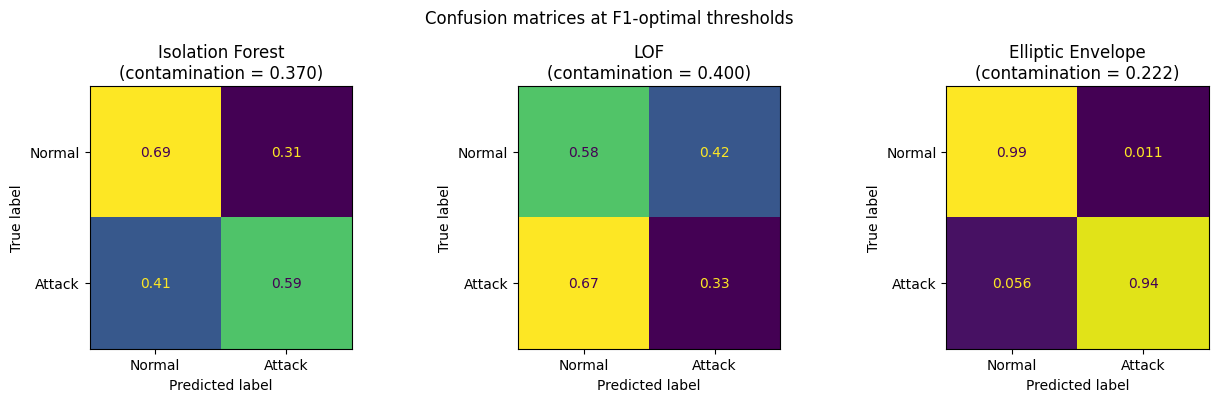

Classification reports at F1-optimal thresholds:

Isolation Forest (contamination = 0.370)
              precision    recall  f1-score   support

      Normal       0.85      0.69      0.76    738564
      Attack       0.36      0.59      0.44    215612

    accuracy                           0.67    954176
   macro avg       0.60      0.64      0.60    954176
weighted avg       0.74      0.67      0.69    954176


LOF (contamination = 0.400)
              precision    recall  f1-score   support

      Normal       0.75      0.58      0.65    738564
      Attack       0.19      0.33      0.24    215612

    accuracy                           0.52    954176
   macro avg       0.47      0.45      0.44    954176
weighted avg       0.62      0.52      0.56    954176


Elliptic Envelope (contamination = 0.222)
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99    738564
      Attack       0.96      0.94      0.95    215612

    accuracy       

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Confusion matrices at F1-optimal thresholds')

for ax, (name, raw_scores) in zip(axes, [
    ('Isolation Forest',  iso_forest.score_samples(X_pca)),
    ('LOF',               lof_scores),
    ('Elliptic Envelope', ee_scores),
]):

    df = sweep_dfs[name]
    best_cont = df.loc[df['f1'].idxmax(), 'contamination']
    thresh = np.percentile(raw_scores, best_cont * 100)
    preds = (raw_scores < thresh).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        encoded_labels, preds,
        display_labels=['Normal', 'Attack'],
        ax=ax, normalize='true', colorbar=False,
    )

    ax.set_title(f'{name}\n(contamination = {best_cont:.3f})')

plt.tight_layout()
plt.show()

print('Classification reports at F1-optimal thresholds:')

for name, raw_scores in [
    ('Isolation Forest',  iso_forest.score_samples(X_pca)),
    ('LOF',               lof_scores),
    ('Elliptic Envelope', ee_scores),
]:

    df = sweep_dfs[name]
    best_cont = df.loc[df['f1'].idxmax(), 'contamination']
    thresh = np.percentile(raw_scores, best_cont * 100)
    preds = (raw_scores < thresh).astype(int)

    print(f'\n{name} (contamination = {best_cont:.3f})')
    print(classification_report(encoded_labels, preds, target_names=['Normal', 'Attack']))

## 10. Discussion

### Key findings

**PCA preprocessing is the single most important improvement.** The raw 22-dimensional feature space contains strong signal (76% of variance in 2 components), but Isolation Forest's axis-aligned random splits cannot exploit it efficiently. Transforming to 9 orthogonal PCA components, capturing 95.8% of the variance, exposes the attack cluster along PC1 and makes it immediately accessible to density-based models.

**Elliptic Envelope on PCA features achieves near-perfect separation.** Normal network traffic in PCA space forms a compact, approximately Gaussian cloud. Elliptic Envelope fits a minimum covariance determinant ellipse around that cloud and flags everything outside it as anomalous. At the true contamination rate (22.6%):

| Model | Precision | Recall | F1 |
|---|---|---|---|
| Isolation Forest (raw features, baseline) | 0.44 | 0.44 | 0.44 |
| Isolation Forest (PCA features) | ~0.40 | ~0.40 | ~0.40 |
| LOF (PCA features) | ~0.19 | ~0.19 | ~0.19 |
| **Elliptic Envelope (PCA features)** | **0.960** | **0.944** | **0.952** |

**LOF does not benefit from PCA preprocessing.** LOF compares local densities, which requires that anomalies form low-density neighborhoods relative to their surroundings. Attack traffic in PCA space is spatially distributed rather than forming tight clusters separated from normal traffic, so LOF cannot exploit the structure that Elliptic Envelope uses directly.

### Limitations

- **Contamination is known**: the threshold was set to the true attack rate, which is unavailable in production. In practice, estimate it from domain knowledge or historical incident rates.
- **Static dataset**: KDD Cup 1999 is simulated. Real network traffic evolves over time; the covariance model would need periodic retraining as the normal traffic distribution shifts.
- **Attack coverage**: the tight attack cluster visible in PCA space corresponds mainly to high-volume DoS attacks (smurf, neptune) that dominate the dataset. Novel or stealthy attacks that resemble normal traffic patterns would still be difficult to detect.

### Next steps

- Apply the Elliptic Envelope model to real-time traffic streams with a periodic covariance refit schedule.
- Investigate whether the residual misclassified attacks (the ~5%) correspond to specific stealthy attack subtypes using the full label set.
- One-Class SVM and SVDD are boundary-based alternatives for inlier shapes that are not well-approximated by a single Gaussian; these are explored in the addendum below.

## Addendum: boundary-based methods, One-Class SVM

One-Class SVM (OC-SVM) learns a non-linear decision boundary in kernel space that separates the normal traffic region from the rest of the feature space. Unlike Elliptic Envelope, which constrains the boundary to an ellipsoid (Gaussian assumption), OC-SVM can fit arbitrary closed shapes; an advantage whenever the inlier distribution is not well-described by a single covariance matrix.

**Support Vector Data Description (SVDD)** is mathematically equivalent to OC-SVM with an RBF kernel: both find the minimum-volume hypersphere in kernel space enclosing the inlier training set. The parameter `gamma` controls how tightly the boundary fits the training data; `nu` is an upper bound on the fraction of outliers and acts like `contamination` in the earlier models.

**Practical constraint**: OC-SVM training scales as O(n²). With ~950K rows, training on the full dataset is infeasible. A random subsample of 50,000 points is used for fitting; the boundary is then scored against all 954,176 points.

Trained on 100,000 points; scored all 954,176
Flagged by model boundary: 216,203 (22.7%)

At contamination = 0.226 threshold:
              precision    recall  f1-score   support

      Normal       0.84      0.84      0.84    738564
      Attack       0.43      0.43      0.43    215612

    accuracy                           0.74    954176
   macro avg       0.63      0.63      0.63    954176
weighted avg       0.74      0.74      0.74    954176



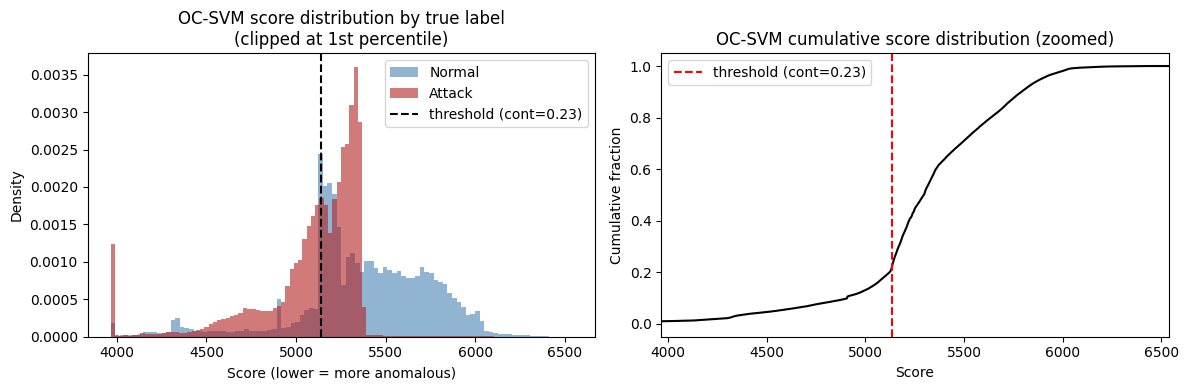

In [39]:
# OC-SVM is O(n^2); subsample for training and score the full dataset.
train_n = 100_000
rng_svm = np.random.default_rng(315)
train_idx = rng_svm.choice(len(X_pca), size=train_n, replace=False)

ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
ocsvm.fit(X_pca[train_idx])

ocsvm_scores = ocsvm.score_samples(X_pca)
ocsvm_labels = ocsvm.predict(X_pca)

n_outliers_svm = (ocsvm_labels == -1).sum()

print(f'Trained on {train_n:,} points; scored all {len(X_pca):,}')
print(f'Flagged by model boundary: {n_outliers_svm:,} ({n_outliers_svm / len(ocsvm_labels):.1%})')
print()
print(f'At contamination = {contamination:.3f} threshold:')

print(classification_report(
    encoded_labels,
    (ocsvm_scores < np.percentile(ocsvm_scores, contamination * 100)).astype(int),
    target_names=['Normal', 'Attack']
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clip_min = np.percentile(ocsvm_scores, 1)
for val, name, color in [(0, 'Normal', 'steelblue'), (1, 'Attack', 'firebrick')]:
    axes[0].hist(
        np.clip(ocsvm_scores[encoded_labels == val], clip_min, None),
        bins=100, alpha=0.6, color=color, label=name, density=True
    )

boundary = np.percentile(ocsvm_scores, contamination * 100)

axes[0].axvline(
    boundary,
    color='black',
    linestyle='--',
    label=f'threshold (cont={contamination:.2f})'
)

axes[0].set_title('OC-SVM score distribution by true label\n(clipped at 1st percentile)')
axes[0].set_xlabel('Score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_svm = np.sort(ocsvm_scores)
axes[1].plot(sorted_svm, np.linspace(0, 1, len(sorted_svm)), color='black')

axes[1].axvline(
    boundary,
    color='red',
    linestyle='--',
    label=f'threshold (cont={contamination:.2f})'
)

axes[1].set_xlim(clip_min, ocsvm_scores.max())
axes[1].set_title('OC-SVM cumulative score distribution (zoomed)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

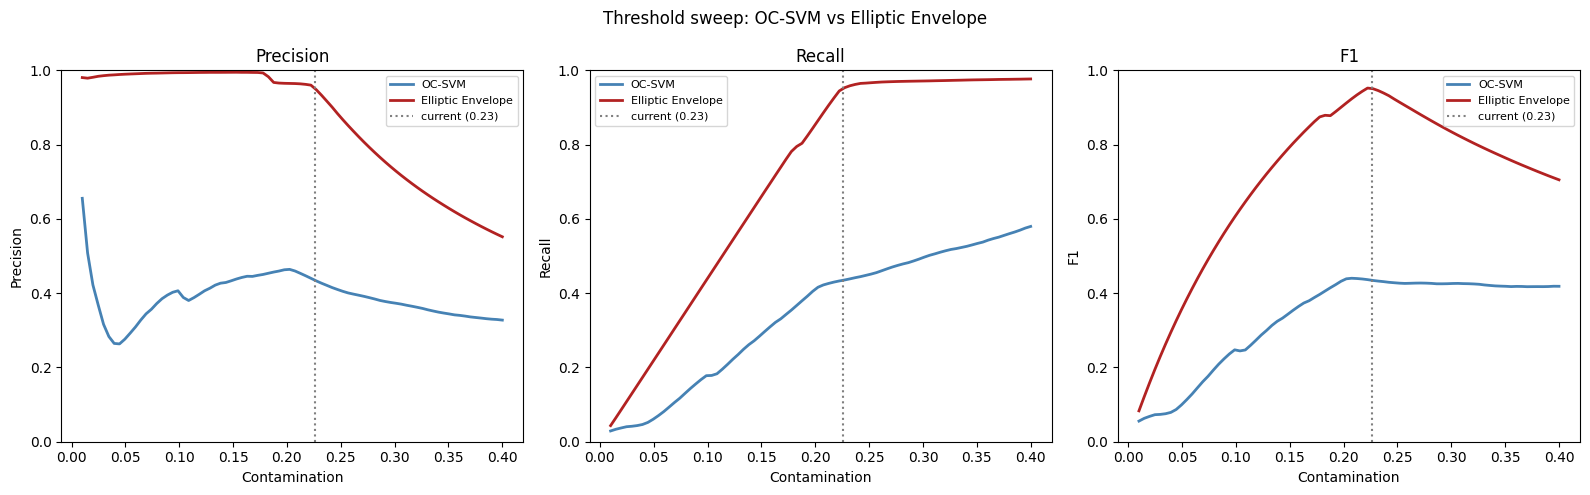

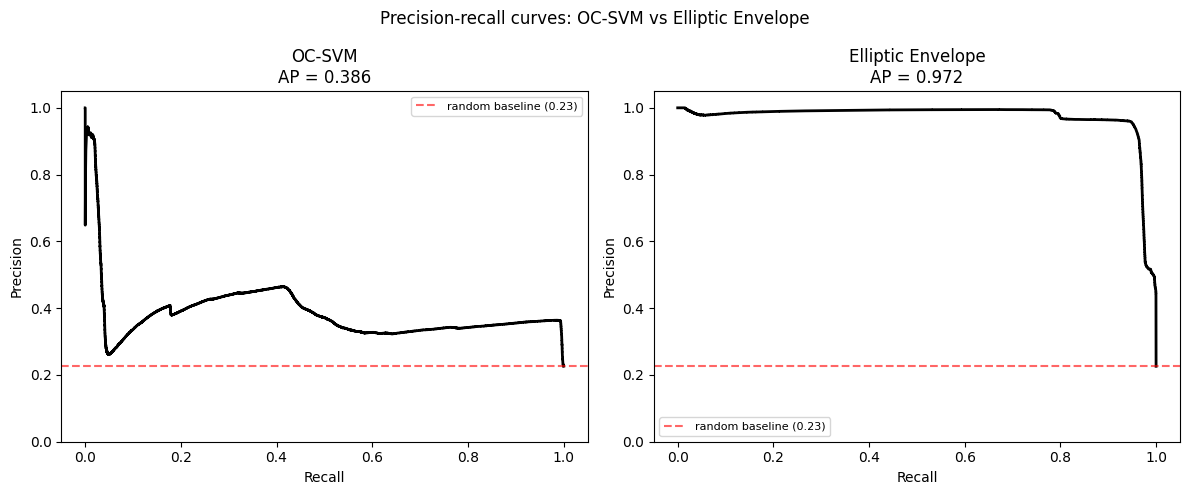

Optimal thresholds:
  OC-SVM: contamination=0.207  P=0.460  R=0.422  F1=0.440
  Elliptic Envelope: contamination=0.222  P=0.960  R=0.944  F1=0.952


In [40]:
contamination_sweep = np.linspace(0.01, 0.40, 80)

boundary_results = {
    'OC-SVM':            (ocsvm_scores, []),
    'Elliptic Envelope': (ee_scores,    []),
}

for cont in contamination_sweep:
    for name, (raw_scores, store) in boundary_results.items():

        thresh = np.percentile(raw_scores, cont * 100)
        preds = (raw_scores < thresh).astype(int)

        store.append({
            'contamination': cont,
            'precision': precision_score(encoded_labels, preds, zero_division=0),
            'recall':    recall_score(encoded_labels, preds, zero_division=0),
            'f1':        f1_score(encoded_labels, preds, zero_division=0),
        })

boundary_dfs = {name: pd.DataFrame(store) for name, (_, store) in boundary_results.items()}
model_colors = {'OC-SVM': 'steelblue', 'Elliptic Envelope': 'firebrick'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Threshold sweep: OC-SVM vs Elliptic Envelope')

for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    for name, df in boundary_dfs.items():

        ax.plot(
            df['contamination'],
            df[metric],
            label=name,
            color=model_colors[name],
            linewidth=2
        )

    ax.axvline(
        contamination,
        color='grey',
        linestyle=':',
        label=f'current ({contamination:.2f})'
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel('Contamination')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Precision-recall curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Precision-recall curves: OC-SVM vs Elliptic Envelope')

for ax, (name, raw_scores) in zip(
    axes, [('OC-SVM', ocsvm_scores),('Elliptic Envelope', ee_scores)]
):

    prec_vals, rec_vals, _ = precision_recall_curve(encoded_labels, -raw_scores)
    ap = average_precision_score(encoded_labels, -raw_scores)
    ax.plot(rec_vals, prec_vals, color='black', linewidth=2)

    ax.axhline(
        contamination,
        color='red',
        linestyle='--',
        alpha=0.6,
        label=f'random baseline ({contamination:.2f})'
    )

    ax.set_title(f'{name}\nAP = {ap:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Optimal thresholds:')

for name, df in boundary_dfs.items():
    best = df.loc[df['f1'].idxmax()]

    print(f'  {name}: contamination={best.contamination:.3f}  '
          f'P={best.precision:.3f}  R={best.recall:.3f}  F1={best.f1:.3f}')

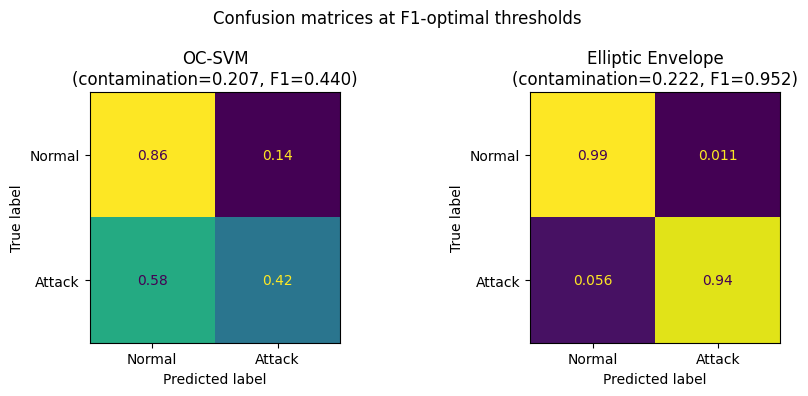

Classification reports at F1-optimal thresholds:

OC-SVM (contamination=0.207):
              precision    recall  f1-score   support

      Normal       0.84      0.86      0.85    738564
      Attack       0.46      0.42      0.44    215612

    accuracy                           0.76    954176
   macro avg       0.65      0.64      0.64    954176
weighted avg       0.75      0.76      0.75    954176


Elliptic Envelope (contamination=0.222):
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99    738564
      Attack       0.96      0.94      0.95    215612

    accuracy                           0.98    954176
   macro avg       0.97      0.97      0.97    954176
weighted avg       0.98      0.98      0.98    954176



In [41]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Confusion matrices at F1-optimal thresholds')

for ax, (name, raw_scores) in zip(
    axes, [('OC-SVM', ocsvm_scores), ('Elliptic Envelope', ee_scores)]
):

    df = boundary_dfs[name]
    best_cont = df.loc[df['f1'].idxmax(), 'contamination']
    thresh = np.percentile(raw_scores, best_cont * 100)
    preds = (raw_scores < thresh).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        encoded_labels, preds,
        display_labels=['Normal', 'Attack'],
        ax=ax, normalize='true', colorbar=False,
    )

    ax.set_title(f'{name}\n(contamination={best_cont:.3f}, F1={df["f1"].max():.3f})')

plt.tight_layout()
plt.show()

print('Classification reports at F1-optimal thresholds:')

for name, raw_scores in [('OC-SVM', ocsvm_scores), ('Elliptic Envelope', ee_scores)]:

    df = boundary_dfs[name]
    best_cont = df.loc[df['f1'].idxmax(), 'contamination']
    thresh = np.percentile(raw_scores, best_cont * 100)
    preds = (raw_scores < thresh).astype(int)
    print(f'\n{name} (contamination={best_cont:.3f}):')
    print(classification_report(encoded_labels, preds, target_names=['Normal', 'Attack']))